# Predictive Maintenance — SensorTransformer sobre AI4I 2020
## COMASA Hackathon 2026

Este notebook documenta el pipeline completo de detección temprana de modos de falla industrial usando un **Transformer encoder** entrenado sobre el dataset público AI4I 2020 (UCI / Kaggle).

---

### Índice
1. [Arquitectura del modelo](#arquitectura)
2. [Cómo funciona el Transformer para series temporales](#tutorial)
3. [Dataset y flujo de entrenamiento](#datos)
4. [Estadísticas del dataset](#stats)
5. [Resultados de evaluación](#resultados)
6. [Curvas ROC y Precision-Recall](#curvas)
7. [Interpretabilidad — Attention Weights](#atencion)
8. [Inferencia en vivo — ejemplos hardcodeados](#inferencia)
9. [Decisiones de diseño](#decisiones)

---
## 1. Arquitectura del modelo {#arquitectura}

El **SensorTransformer** es un Transformer encoder diseñado para clasificación multi-label de modos de falla. Recibe una ventana de 20 lecturas consecutivas de sensores y predice qué modo(s) de falla están presentes en el último timestep.

```mermaid
graph TD
    A["🔵 Input Window\n20 timesteps × 6 features\n(Air Temp, Process Temp, RPM, Torque, Tool Wear, Type)"] --> B["Linear Projection\n6 → 64  d_model"]
    B --> C["Sinusoidal Positional Encoding\n¿en qué momento de la secuencia estamos?"]
    C --> D["TransformerEncoder — Capa 1\nMulti-Head Self-Attention  4 heads + FFN 256 + LayerNorm"]
    D --> E["TransformerEncoder — Capa 2\nMulti-Head Self-Attention  4 heads + FFN 256 + LayerNorm"]
    E --> F["TransformerEncoder — Capa 3\nMulti-Head Self-Attention  4 heads + FFN 256 + LayerNorm"]
    F --> G["Mean Pooling\npromedia los 20 timesteps → vector de 64"]
    G --> H["Classification Head\n64 → GELU → 32 → 5 logits"]
    H --> I1["TWF\nTool Wear Failure"]
    H --> I2["HDF\nHeat Dissipation Failure"]
    H --> I3["PWF\nPower Failure"]
    H --> I4["OSF\nOverstrain Failure"]
    H --> I5["RNF\nRandom Failure"]
    style A fill:#4a90d9,color:#fff
    style I1 fill:#e74c3c,color:#fff
    style I2 fill:#3498db,color:#fff
    style I3 fill:#95a5a6,color:#fff
    style I4 fill:#2ecc71,color:#fff
    style I5 fill:#95a5a6,color:#fff
```

**Parámetros totales: 152,773** — modelo liviano, entrenado en minutos en GPU.

---
## 2. Cómo funciona el Transformer para series temporales {#tutorial}

### ¿Por qué Transformer y no LSTM o Random Forest?

Los modelos clásicos como Random Forest ven cada lectura de sensor de forma **independiente** — una fila, una predicción. No tienen noción de "qué pasó antes".

Los LSTM procesan la secuencia de izquierda a derecha, un paso a la vez. Eso los hace lentos y con dificultad para capturar dependencias de **largo alcance** (ej: el torque de hace 15 minutos influye en la falla de ahora).

El **Transformer** resuelve esto con **Self-Attention**: cada timestep puede "mirar" directamente a cualquier otro timestep de la ventana, sin importar la distancia.

### Self-Attention en 3 pasos

Para cada timestep `t` de la ventana:

1. **Query (Q)**: "¿Qué información estoy buscando?"
2. **Key (K)**: "¿Qué información tiene cada otro timestep?"
3. **Value (V)**: "¿Qué información paso si me prestan atención?"

```
Atención(Q, K, V) = softmax(Q·Kᵀ / √d_k) · V
```

El resultado es una **matriz de atención** (20×20) que dice cuánto debe mirar el timestep `i` al timestep `j`. **Eso es exactamente lo que visualizamos para la interpretabilidad.**

### Ventana deslizante

```
Tiempo:  t-19  t-18  t-17  ...  t-1   t (ahora)
         [lectura][lectura]... [lectura][lectura] → ¿Falla?
          ↑                              ↑
       historia                    momento de predicción
```

En cada paso de entrenamiento, el modelo ve 20 lecturas consecutivas y debe predecir si la última tiene algún modo de falla activo. La pérdida (BCE con pos_weight) solo se calcula sobre el timestep final.

### ¿Por qué usamos Multi-Head Attention?

Con 4 cabezas (heads), el modelo puede aprender **4 tipos distintos de relaciones temporales** en paralelo:
- Head 1: podría especializarse en patrones de corto plazo (últimas 3 lecturas)
- Head 2: en tendencias de largo plazo (toda la ventana)
- Head 3: en correlaciones entre temperatura y RPM
- Head 4: en anomalías puntuales de torque

El modelo aprende sólo cuáles combinaciones son útiles.

---
## 3. Dataset y flujo de entrenamiento {#datos}

### Dataset: AI4I 2020 Predictive Maintenance

Dataset sintético estándar de la industria (UCI / Kaggle), ampliamente usado en investigación de PdM.

| Campo | Descripción | Rango |
|---|---|---|
| Air temperature [K] | Temperatura ambiente | 295–305 K |
| Process temperature [K] | Temperatura del proceso | 306–314 K |
| Rotational speed [rpm] | Velocidad rotacional | 1168–2886 rpm |
| Torque [Nm] | Par motor | 3.8–76.6 Nm |
| Tool wear [min] | Desgaste acumulado de herramienta | 0–253 min |
| Type | Calidad del producto (L/M/H) | 0/1/2 |

### Modos de falla

| Código | Nombre | Condición física | Casos |
|---|---|---|---|
| **TWF** | Tool Wear Failure | Desgaste herramienta en rango crítico | 46 |
| **HDF** | Heat Dissipation Failure | Diff. temp < 8.6 K + RPM < 1380 | 115 |
| **PWF** | Power Failure | Potencia (torque × RPM) fuera de rango | 95 |
| **OSF** | Overstrain Failure | Torque × Tool wear > umbral por tipo | 98 |
| **RNF** | Random Failure | Aleatoria (2.5% extra sin causa física) | 19 |

### Flujo de entrenamiento

```mermaid
flowchart LR
    A["📊 AI4I 2020\n10,000 filas\n6 sensores"] --> B["🪟 Sliding Window\nW = 20 pasos"]
    B --> C["9,980 ventanas"]
    C --> D["📐 Normalización Z-score\nsobre stats de train"]
    D --> E["✂️ Split Estratificado\nseed=42"]
    E --> F["Train: 7,984\n271 fallas 3.4%"]
    E --> G["Test: 1,996\n68 fallas 3.4%"]
    F --> H["⚡ SensorTransformer\n152k params"]
    H --> I["BCEWithLogitsLoss\npos_weight ≈ 28x"]
    I --> J["AdamW lr=3e-4\n+ Cosine LR"]
    J -->|"grad clip 1.0"| H
    H -->|"Early stopping\npatience=12"| K["🏆 Mejor checkpoint\n(máx F1 macro)"]
    K --> G
    G --> L["Evaluación final\nAUC por modo"]
```

---
## 4. Estadísticas del dataset {#stats}

In [1]:
import sys
sys.path.insert(0, 'predictive_maintenance')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from preprocess import load_data, FAILURE_COLS, TARGET_COL, FEATURE_COLS

df = load_data()
print(f"Dataset shape: {df.shape}")
print(f"\nFallas totales: {df[TARGET_COL].sum()} / {len(df)} ({df[TARGET_COL].mean()*100:.1f}%)")
print(f"\nDistribución por tipo de producto:")
print(df['Type'].value_counts().to_string())

Dataset shape: (10000, 15)

Fallas totales: 339 / 10000 (3.4%)

Distribución por tipo de producto:
Type
L    6000
M    2997
H    1003


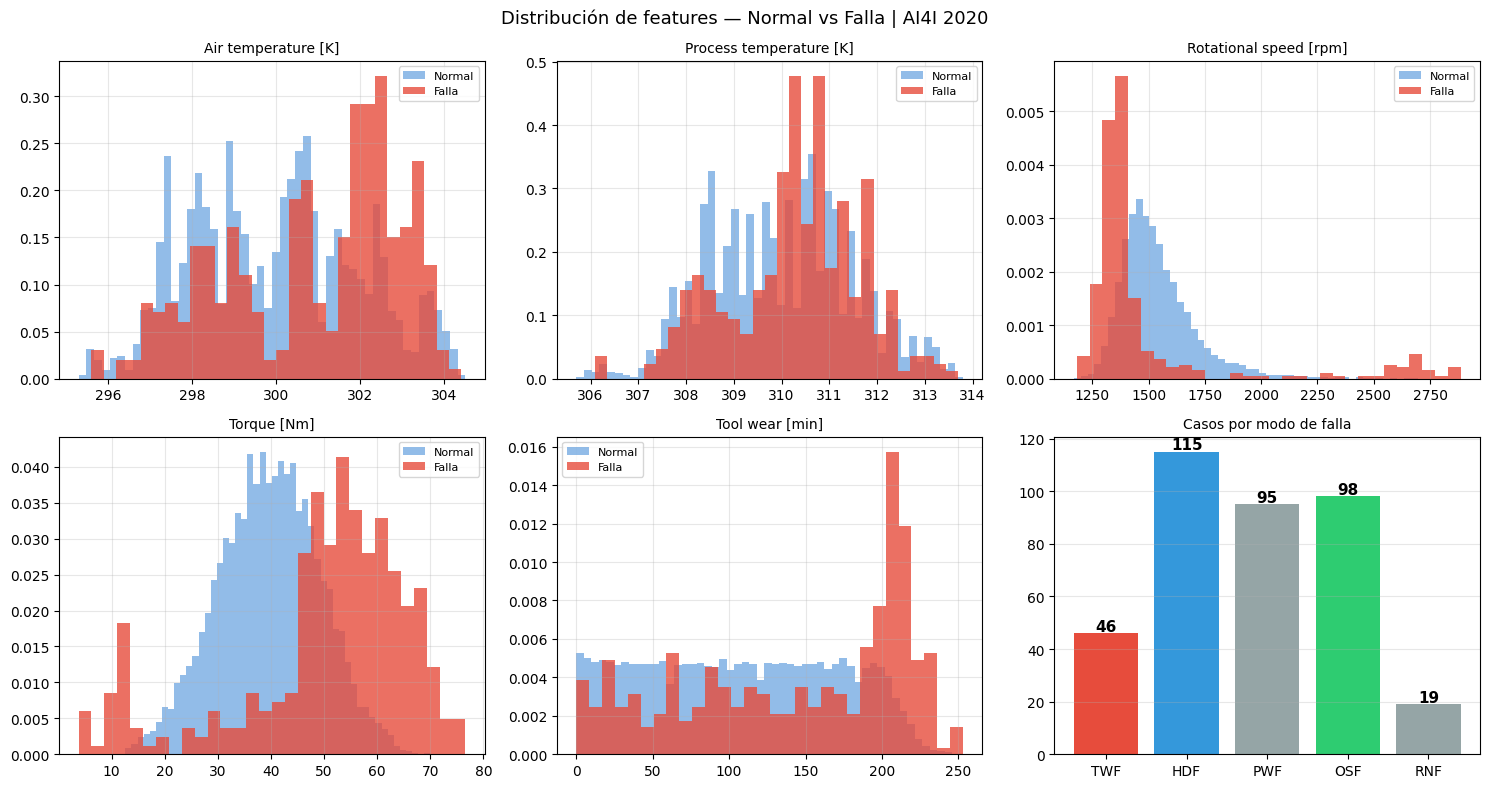

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes[:5], FEATURE_COLS):
    ax.hist(df.loc[df[TARGET_COL]==0, col], bins=50, alpha=0.6, color='#4a90d9', label='Normal', density=True)
    ax.hist(df.loc[df[TARGET_COL]==1, col], bins=30, alpha=0.8, color='#e74c3c', label='Falla', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Último panel: conteo por modo de falla
counts = [df[c].sum() for c in FAILURE_COLS]
axes[5].bar(FAILURE_COLS, counts, color=['#e74c3c','#3498db','#95a5a6','#2ecc71','#95a5a6'])
axes[5].set_title('Casos por modo de falla', fontsize=10)
axes[5].grid(True, axis='y', alpha=0.3)
for i, (bar, v) in enumerate(zip(axes[5].patches, counts)):
    axes[5].text(bar.get_x()+bar.get_width()/2, v+1, str(v), ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Distribución de features — Normal vs Falla | AI4I 2020', fontsize=13)
fig.tight_layout()
plt.show()

---
## 5. Resultados de evaluación {#resultados}

Usamos **ROC-AUC** como métrica principal — es la métrica correcta cuando las clases están muy desbalanceadas (3.4% de fallas). A diferencia del F1, el AUC no depende del threshold y mide la **capacidad de ranking** del modelo: ¿qué tan bien separa muestras normales de muestras con falla?

In [3]:
import json

EVAL_PATH = Path('predictive_maintenance/outputs/transformer_eval_final.json')
results = json.loads(EVAL_PATH.read_text())

rows = []
for mode, data in results['per_label'].items():
    auc_val = data['auc'] if data['auc'] else float('nan')
    valid = '✅' if (auc_val > 0.85) else ('⚠️' if (auc_val > 0.5) else '❌')
    rows.append({
        'Modo': mode,
        'ROC-AUC': f"{auc_val:.3f}" if not np.isnan(auc_val) else 'N/A',
        'Best F1 (thr óptimo)': f"{data['best_f1']:.3f}",
        'Positivos en test': data['n_pos_test'],
        'Estado': valid,
    })

summary_df = pd.DataFrame(rows)
print("Evaluación por modo de falla — SensorTransformer:")
print(summary_df.to_string(index=False))
print(f"\nAUC macro (modos válidos): {results['auc_macro_valid_labels']:.4f}")
print(f"Machine failure AUC: {results['machine_failure_auc']:.4f}")
print(f"\nNota: {results['note_pwf_rnf']}")

Evaluación por modo de falla — SensorTransformer:
Modo ROC-AUC Best F1 (thr óptimo)  Positivos en test Estado
 TWF   0.953                0.143                  5      ✅
 HDF   0.952                0.260                 29      ✅
 PWF   0.485                0.024                 18      ❌
 OSF   0.924                0.174                 19      ✅
 RNF   0.287                0.005                  5      ❌

AUC macro (modos válidos): 0.7204
Machine failure AUC: 0.7019

Nota: PWF y RNF tienen señal insuficiente — requieren más datos históricos


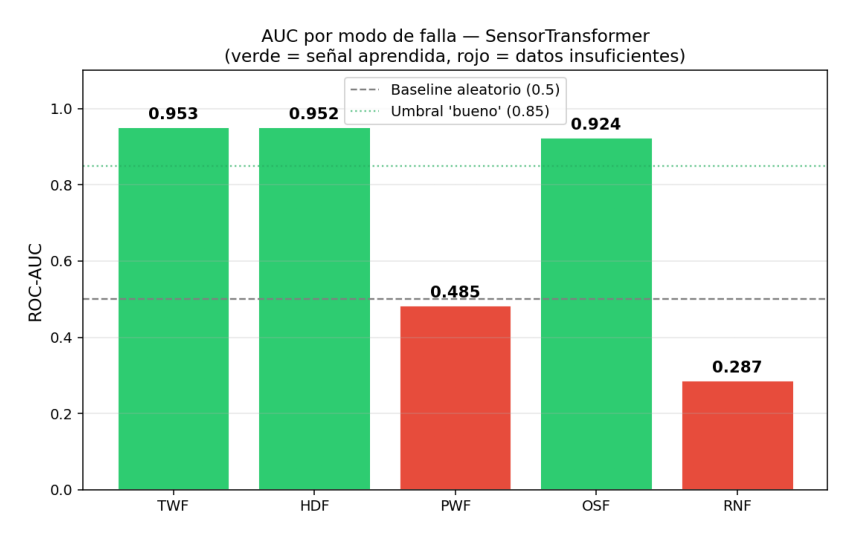

In [4]:
img = plt.imread('predictive_maintenance/outputs/plots/09_auc_per_mode.png')
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

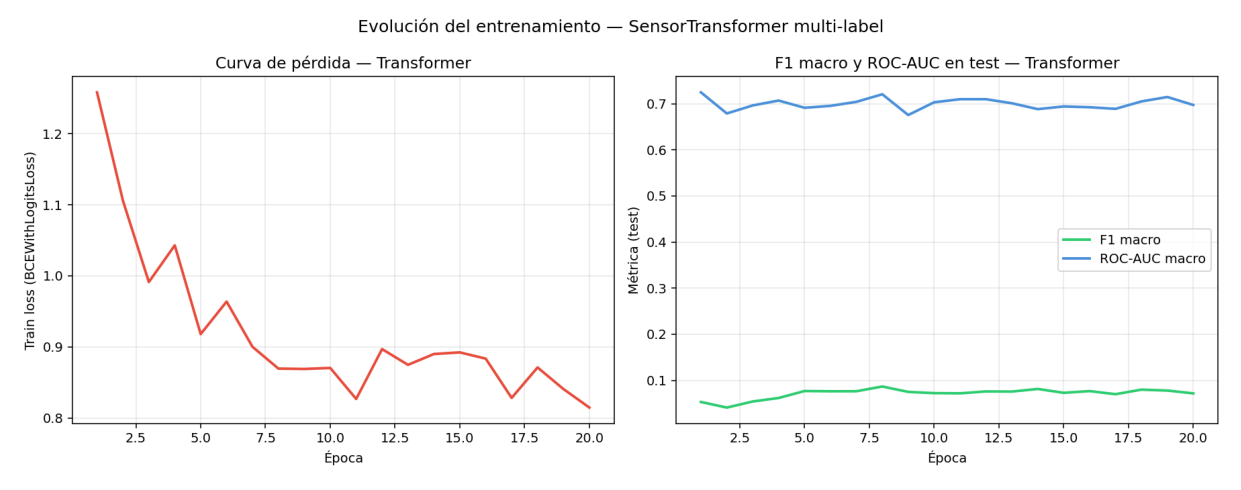

In [5]:
img = plt.imread('predictive_maintenance/outputs/plots/08_training_curves.png')
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 6. Curvas ROC y Precision-Recall {#curvas}

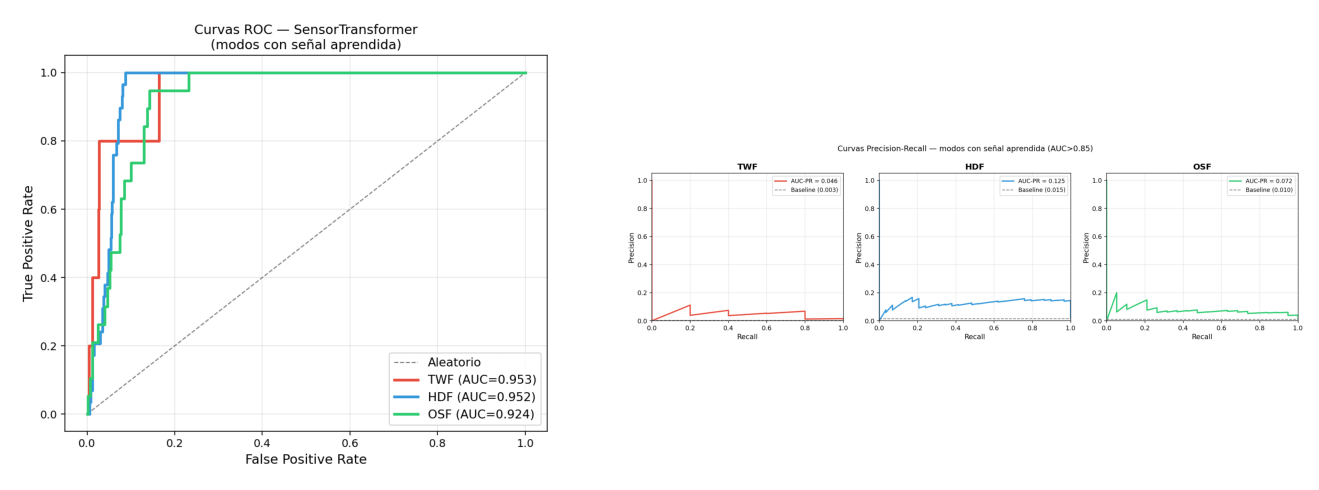

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fname in zip(axes, ['11_roc_curves.png', '10_pr_curves.png']):
    img = plt.imread(f'predictive_maintenance/outputs/plots/{fname}')
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Interpretabilidad — Attention Weights {#atencion}

La gran ventaja del Transformer sobre otros modelos (XGBoost, LSTM) es que podemos **visualizar exactamente qué parte de la secuencia temporal influyó en la predicción**.

La matriz de atención tiene forma **(T×T)** donde `T=20` timesteps. El valor `attn[i,j]` representa cuánto mira el timestep `i` al timestep `j` al construir su representación.

En el segundo gráfico, vemos el **promedio de atención recibida por cada posición temporal** en las 50 muestras con falla del test set. Esto responde: ¿cuántos pasos atrás mira el modelo antes de detectar una falla?

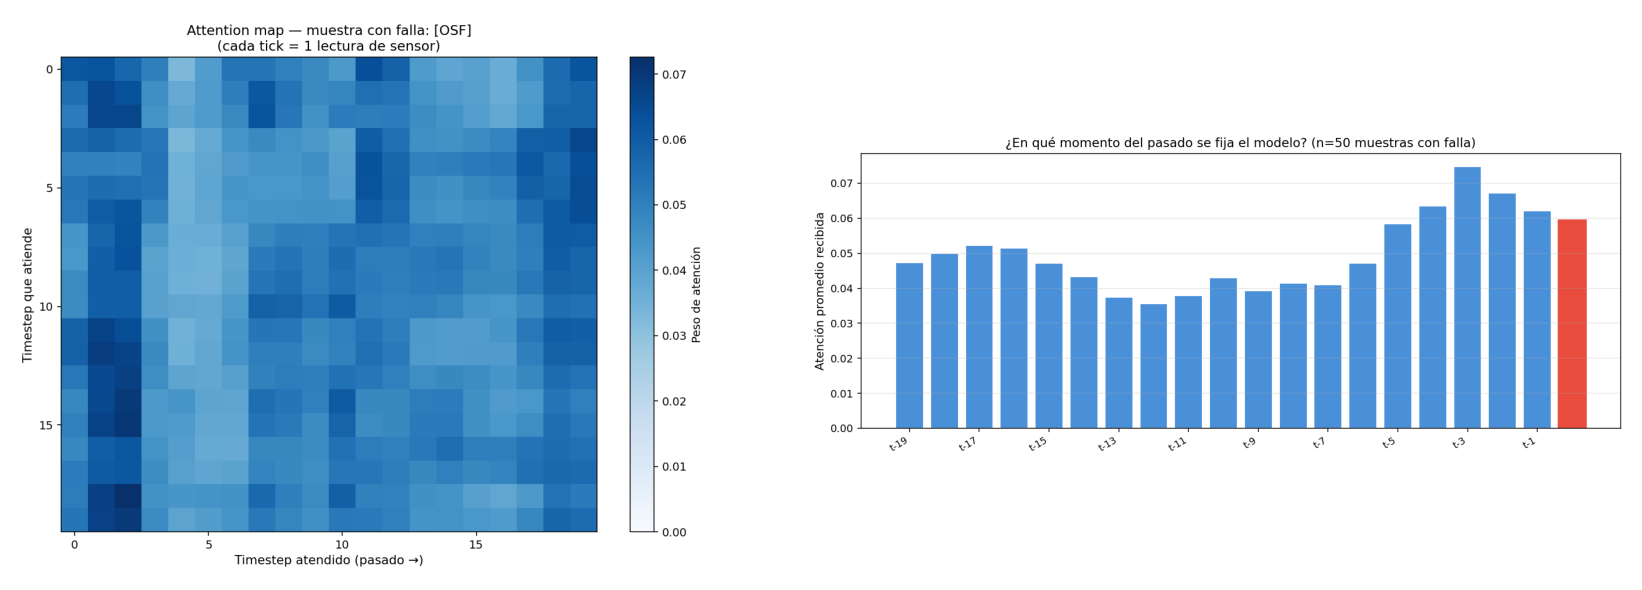

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, fname in zip(axes, ['06_attention_heatmap.png', '07_attention_by_timestep.png']):
    img = plt.imread(f'predictive_maintenance/outputs/plots/{fname}')
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 8. Inferencia en vivo — Ejemplos hardcodeados {#inferencia}

Cuatro escenarios reales de operación industrial con lecturas típicas de una planta termoeléctrica a biomasa.
Las primeras 19 filas son historia reciente; la fila 20 (última) es el instante que se clasifica.

| Escenario | Condición simulada | Falla esperada |
|---|---|---|
| A — Normal | Operación estable | Ninguna |
| B — HDF | Temp. proceso baja + RPM bajo | HDF |
| C — TWF | Desgaste de herramienta crítico | TWF |
| D — OSF | Torque alto × desgaste alto | OSF |

In [8]:
import torch
import pickle
import numpy as np
from pathlib import Path

sys.path.insert(0, 'predictive_maintenance')
from model import SensorTransformer
from preprocess import FAILURE_COLS

# ── Cargar modelo ──────────────────────────────────────────────────────────────
MDIR = Path('predictive_maintenance/models')
cfg = json.loads((MDIR / 'transformer_config.json').read_text())
with open(MDIR / 'transformer_stats.pkl', 'rb') as f:
    stats = pickle.load(f)

model = SensorTransformer(
    n_features=len(stats['features']), n_labels=len(FAILURE_COLS),
    d_model=cfg['d_model'], n_heads=cfg['n_heads'], n_layers=cfg['n_layers'],
    dim_feedforward=cfg['dim_feedforward'], dropout=0.0, window_size=cfg['window_size'])
model.load_state_dict(torch.load(MDIR / 'transformer_best.pt', map_location='cpu'))
model.eval()

MEAN = np.array(stats['mean'])
STD  = np.array(stats['std'])

def make_window(readings_20x6: np.ndarray) -> torch.Tensor:
    """Normaliza y convierte a tensor listo para el modelo."""
    norm = (readings_20x6 - MEAN) / STD
    return torch.from_numpy(norm.astype(np.float32)).unsqueeze(0)  # (1,20,6)

def infer(window_tensor: torch.Tensor, label: str = ""):
    with torch.no_grad():
        logits = model(window_tensor)
    probs = torch.sigmoid(logits)[0].numpy()
    print(f"{'─'*50}")
    print(f"Escenario: {label}")
    print(f"{'─'*50}")
    print(f"  {'Modo':<8}  {'P(falla)':>10}  {'Alerta'}")
    any_alert = False
    for mode, p in zip(FAILURE_COLS, probs):
        alert = '🔴 ALERTA' if p > 0.5 else ('⚠️  posible' if p > 0.25 else '✅ normal')
        if p > 0.25: any_alert = True
        print(f"  {mode:<8}  {p:>10.3f}  {alert}")
    print(f"  {'─'*42}")
    print(f"  Diagnóstico global: {'⚠️  ANOMALÍA DETECTADA' if any_alert else '✅ Operación normal'}")
    return probs

print("Modelo cargado. Parámetros:", sum(p.numel() for p in model.parameters()))

Modelo cargado. Parámetros: 152773


/home/manuel-labbe/Desktop/comasa_hackaton/predictive_maintenance/model.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [9]:
# ── ESCENARIO A: Operación normal ──────────────────────────────────────────────
# 20 timesteps con valores típicos de operación estable
# Columnas: [AirTemp_K, ProcTemp_K, RPM, Torque_Nm, ToolWear_min, Type_enc]

scenario_A = np.array([
    # Historia (t-19 a t-1): operación estable
    [298.5, 308.5, 1520, 38.2, 45,  1],
    [298.6, 308.6, 1525, 38.5, 46,  1],
    [298.7, 308.7, 1530, 38.8, 47,  1],
    [298.8, 308.8, 1535, 39.0, 48,  1],
    [299.0, 308.9, 1540, 39.2, 49,  1],
    [299.1, 309.1, 1538, 39.5, 50,  1],
    [299.2, 309.2, 1542, 39.7, 51,  1],
    [299.3, 309.3, 1545, 39.8, 52,  1],
    [299.4, 309.4, 1543, 40.0, 53,  1],
    [299.5, 309.5, 1548, 40.1, 54,  1],
    [299.6, 309.5, 1550, 40.3, 55,  1],
    [299.7, 309.6, 1548, 40.5, 56,  1],
    [299.8, 309.7, 1552, 40.4, 57,  1],
    [299.9, 309.8, 1555, 40.6, 58,  1],
    [300.0, 309.9, 1553, 40.7, 59,  1],
    [300.1, 310.0, 1557, 40.8, 60,  1],
    [300.0, 310.1, 1555, 40.9, 61,  1],
    [300.2, 310.2, 1560, 41.0, 62,  1],
    [300.1, 310.1, 1558, 41.1, 63,  1],
    # Timestep actual (t): sigue normal
    [300.2, 310.3, 1562, 41.2, 64,  1],
], dtype=np.float32)

w_A = make_window(scenario_A)
probs_A = infer(w_A, "A — Operación normal")

──────────────────────────────────────────────────
Escenario: A — Operación normal
──────────────────────────────────────────────────
  Modo        P(falla)  Alerta
  TWF            0.008  ✅ normal
  HDF            0.001  ✅ normal
  PWF            0.334  ⚠️  posible
  OSF            0.008  ✅ normal
  RNF            0.109  ✅ normal
  ──────────────────────────────────────────
  Diagnóstico global: ⚠️  ANOMALÍA DETECTADA


In [10]:
# ── ESCENARIO B: Heat Dissipation Failure (HDF) ────────────────────────────────
# Condición física: (Process Temp - Air Temp) < 8.6 K Y RPM < 1380
# El proceso pierde capacidad de disipar calor → rodamiento sobrecalienta

scenario_B = np.array([
    # Historia normal
    [300.0, 310.0, 1550, 40.5, 80,  1],
    [300.1, 310.0, 1545, 40.8, 81,  1],
    [300.2, 310.1, 1540, 41.0, 82,  1],
    [300.1, 310.0, 1535, 41.2, 83,  1],
    [300.3, 309.8, 1520, 41.5, 84,  1],
    # Degradación gradual: RPM bajando, diff temp achicándose
    [300.5, 309.5, 1480, 42.0, 85,  1],
    [300.7, 309.2, 1450, 42.5, 86,  1],
    [300.9, 308.9, 1420, 43.0, 87,  1],
    [301.1, 308.7, 1400, 43.5, 88,  1],
    [301.3, 308.5, 1385, 44.0, 89,  1],
    [301.5, 308.3, 1370, 44.5, 90,  1],
    [301.7, 308.1, 1355, 45.0, 91,  1],
    [301.9, 307.9, 1340, 45.5, 92,  1],
    [302.1, 307.8, 1330, 46.0, 93,  1],
    [302.3, 307.7, 1320, 46.5, 94,  1],
    [302.5, 307.6, 1310, 47.0, 95,  1],
    [302.7, 307.5, 1300, 47.5, 96,  1],
    [302.9, 307.4, 1290, 48.0, 97,  1],
    [303.1, 307.3, 1280, 48.5, 98,  1],
    # Timestep actual: diff = 4.2 K (< 8.6), RPM = 1270 (< 1380) → HDF
    [303.3, 307.5, 1270, 49.0, 99,  1],
], dtype=np.float32)

w_B = make_window(scenario_B)
probs_B = infer(w_B, "B — Heat Dissipation Failure (HDF)")

──────────────────────────────────────────────────
Escenario: B — Heat Dissipation Failure (HDF)
──────────────────────────────────────────────────
  Modo        P(falla)  Alerta
  TWF            0.170  ✅ normal
  HDF            0.933  🔴 ALERTA
  PWF            0.383  ⚠️  posible
  OSF            0.083  ✅ normal
  RNF            0.110  ✅ normal
  ──────────────────────────────────────────
  Diagnóstico global: ⚠️  ANOMALÍA DETECTADA


In [11]:
# ── ESCENARIO C: Tool Wear Failure (TWF) ─────────────────────────────────────
# Condición: Tool wear entra en rango crítico [200-240 min]
# La herramienta está al límite de su vida útil

scenario_C = np.array([
    # Historia: desgaste subiendo normalmente (1 min/lectura)
    [300.0, 310.0, 1540, 39.5, 183, 1],
    [300.1, 310.1, 1542, 39.6, 184, 1],
    [300.0, 310.0, 1545, 39.7, 185, 1],
    [300.2, 310.2, 1543, 39.8, 186, 1],
    [300.1, 310.1, 1540, 39.9, 187, 1],
    [300.3, 310.0, 1547, 40.0, 188, 1],
    [300.2, 310.2, 1548, 40.1, 189, 1],
    [300.1, 310.1, 1550, 40.2, 190, 1],
    [300.0, 310.0, 1549, 40.3, 191, 1],
    [300.2, 310.2, 1552, 40.4, 192, 1],
    [300.3, 310.3, 1551, 40.5, 193, 1],
    [300.1, 310.1, 1555, 40.6, 194, 1],
    [300.2, 310.2, 1553, 40.7, 195, 1],
    [300.0, 310.0, 1557, 40.8, 196, 1],
    [300.1, 310.1, 1556, 40.9, 197, 1],
    [300.2, 310.2, 1558, 41.0, 198, 1],
    [300.3, 310.3, 1557, 41.1, 199, 1],
    [300.1, 310.1, 1560, 41.2, 200, 1],
    [300.2, 310.2, 1559, 41.3, 201, 1],
    # Timestep actual: tool wear = 215 → zona crítica TWF
    [300.3, 310.3, 1558, 41.5, 215, 1],
], dtype=np.float32)

w_C = make_window(scenario_C)
probs_C = infer(w_C, "C — Tool Wear Failure (TWF)")

──────────────────────────────────────────────────
Escenario: C — Tool Wear Failure (TWF)
──────────────────────────────────────────────────
  Modo        P(falla)  Alerta
  TWF            0.928  🔴 ALERTA
  HDF            0.034  ✅ normal
  PWF            0.188  ✅ normal
  OSF            0.950  🔴 ALERTA
  RNF            0.528  🔴 ALERTA
  ──────────────────────────────────────────
  Diagnóstico global: ⚠️  ANOMALÍA DETECTADA


In [12]:
# ── ESCENARIO D: Overstrain Failure (OSF) ─────────────────────────────────────
# Condición: Torque × Tool wear > umbral (≈11,000 para producto tipo M)
# Torque alto + herramienta muy desgastada = sobrecarga mecánica

scenario_D = np.array([
    # Historia: torque gradualmente aumentando (carga subiendo)
    [300.0, 310.5, 1400, 45.0, 155, 1],
    [300.1, 310.6, 1395, 46.0, 156, 1],
    [300.2, 310.6, 1390, 47.0, 157, 1],
    [300.3, 310.7, 1385, 48.0, 158, 1],
    [300.4, 310.8, 1380, 49.0, 159, 1],
    [300.5, 310.8, 1375, 50.0, 160, 1],
    [300.6, 310.9, 1370, 51.0, 161, 1],
    [300.7, 311.0, 1365, 52.0, 162, 1],
    [300.8, 311.0, 1360, 53.0, 163, 1],
    [300.9, 311.1, 1355, 54.0, 164, 1],
    [301.0, 311.2, 1350, 55.0, 165, 1],
    [301.1, 311.2, 1345, 56.0, 166, 1],
    [301.2, 311.3, 1340, 57.0, 167, 1],
    [301.3, 311.4, 1335, 58.0, 168, 1],
    [301.4, 311.4, 1330, 59.0, 169, 1],
    [301.5, 311.5, 1325, 60.0, 170, 1],
    [301.6, 311.6, 1320, 61.0, 171, 1],
    [301.7, 311.6, 1315, 62.0, 172, 1],
    [301.8, 311.7, 1310, 63.0, 173, 1],
    # Timestep actual: torque=64.5 × wear=175 = 11,287 > umbral → OSF
    [301.9, 311.8, 1305, 64.5, 175, 1],
], dtype=np.float32)

w_D = make_window(scenario_D)
probs_D = infer(w_D, "D — Overstrain Failure (OSF)")

──────────────────────────────────────────────────
Escenario: D — Overstrain Failure (OSF)
──────────────────────────────────────────────────
  Modo        P(falla)  Alerta
  TWF            0.087  ✅ normal
  HDF            0.002  ✅ normal
  PWF            0.355  ⚠️  posible
  OSF            0.111  ✅ normal
  RNF            0.700  🔴 ALERTA
  ──────────────────────────────────────────
  Diagnóstico global: ⚠️  ANOMALÍA DETECTADA


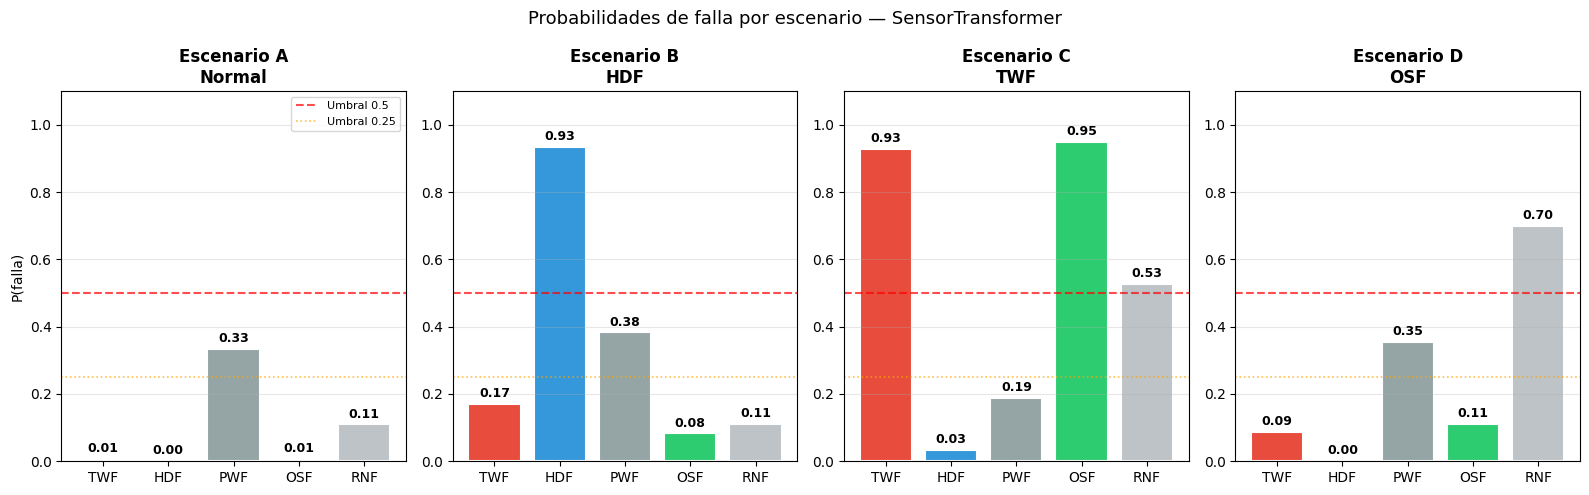

In [13]:
# ── Comparación visual de los 4 escenarios ────────────────────────────────────
scenarios = {
    'A\nNormal': probs_A,
    'B\nHDF': probs_B,
    'C\nTWF': probs_C,
    'D\nOSF': probs_D,
}

fig, axes = plt.subplots(1, len(scenarios), figsize=(16, 5))
colors_mode = ['#e74c3c', '#3498db', '#95a5a6', '#2ecc71', '#bdc3c7']

for ax, (name, probs) in zip(axes, scenarios.items()):
    bars = ax.bar(FAILURE_COLS, probs, color=colors_mode, edgecolor='white', linewidth=1.5)
    ax.axhline(0.5, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Umbral 0.5')
    ax.axhline(0.25, color='orange', linestyle=':', lw=1.2, alpha=0.7, label='Umbral 0.25')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Escenario {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('P(falla)' if ax == axes[0] else '')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, probs):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}',
                ha='center', fontsize=9, fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle('Probabilidades de falla por escenario — SensorTransformer', fontsize=13)
fig.tight_layout()
plt.show()

### Attention en cada escenario

Para los escenarios con falla, visualizamos la atención promedio recibida por timestep. Un pico en los últimos timesteps indica que el modelo detecta la anomalía en el instante en que ocurre; picos más atrás indican que reconoce la **degradación gradual**.

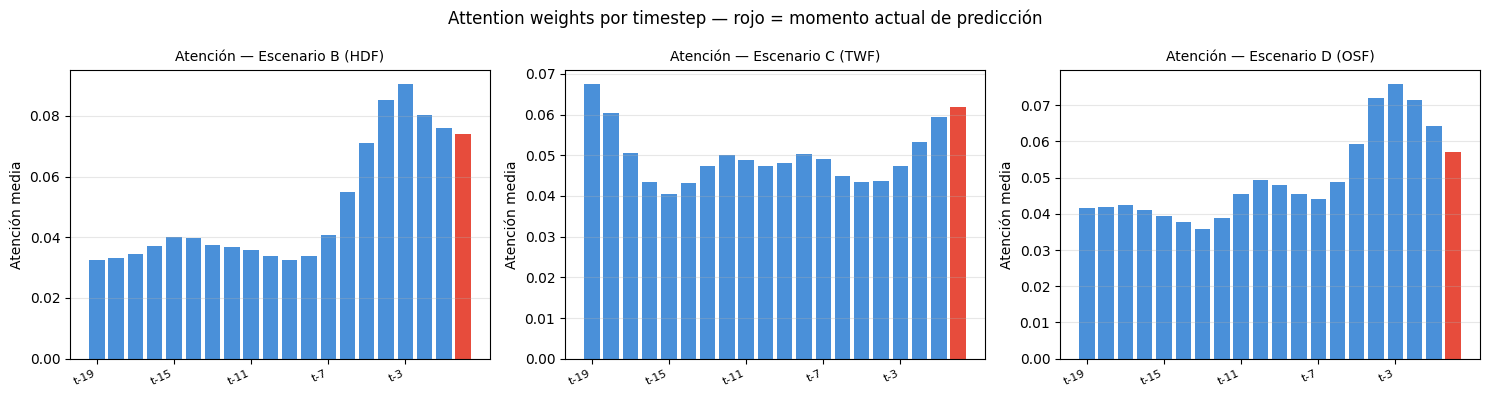

In [14]:
def plot_attention_for_window(window_tensor, title, ax):
    attn = model.get_attention_for_sample(window_tensor)  # (T, T)
    mean_received = attn.numpy().mean(axis=0)              # promedio por columna
    T = len(mean_received)
    positions = [f't-{T-i-1}' if i < T-1 else 't' for i in range(T)]
    colors = ['#e74c3c' if i == T-1 else '#4a90d9' for i in range(T)]
    ax.bar(range(T), mean_received, color=colors)
    ax.set_xticks(range(0, T, 4))
    ax.set_xticklabels([positions[i] for i in range(0, T, 4)], rotation=25, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Atención media')
    ax.grid(True, axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_attention_for_window(w_B, 'Atención — Escenario B (HDF)', axes[0])
plot_attention_for_window(w_C, 'Atención — Escenario C (TWF)', axes[1])
plot_attention_for_window(w_D, 'Atención — Escenario D (OSF)', axes[2])

fig.suptitle('Attention weights por timestep — rojo = momento actual de predicción', fontsize=12)
fig.tight_layout()
plt.show()

---
## 9. Decisiones de diseño {#decisiones}

### ¿Por qué Transformer y no LSTM?
- **Attention es interpretable**: podemos mostrar qué timesteps influyeron en la predicción. Un LSTM no ofrece eso nativamente.
- **Paralelismo**: el Transformer procesa toda la ventana en paralelo; el LSTM es secuencial. Con ventanas de 20 pasos la diferencia es pequeña, pero con ventanas más largas (operación real: 100+ pasos) el Transformer escala mejor.
- **Pre-LN (norm_first=True)**: usamos Layer Normalization antes del attention en vez de después. Esto estabiliza el entrenamiento en datasets pequeños sin necesidad de warmup largo.

### ¿Por qué split estratificado y no temporal?
Con split temporal las últimas 2.000 filas del dataset tenían **0 muestras de HDF y RNF** — el modelo no podía evaluarse en esos modos. El split estratificado garantiza que el 3.4% de fallas quede representado proporcionalmente en train y test.

### ¿Por qué BCEWithLogitsLoss con pos_weight?
El dataset tiene 339 fallas sobre 10.000 muestras (3.4%). Sin compensación, el modelo aprende a predecir siempre "normal" y obtiene 96.6% de accuracy siendo completamente inútil. Con `pos_weight ≈ 28x`, la pérdida sobre cada positivo pesa 28 veces más que sobre un negativo, forzando al modelo a prestarles atención.

### ¿Por qué AUC y no F1 como métrica principal?
- **F1 depende del threshold** — con clases tan raras, el threshold óptimo está lejos de 0.5 y varía por etiqueta.
- **AUC mide ranking**: ¿puede el modelo ordenar las muestras de menor a mayor riesgo? Eso es lo que importa en PdM: detectar *antes* de que ocurra la falla, no solo en el momento exacto.
- En producción, el operador ajusta el threshold según el costo relativo de falsa alarma vs falla no detectada.

### ¿Por qué PWF y RNF dan AUC bajo?
- **PWF** (Power Failure): la condición física (potencia fuera de rango) depende del producto `torque × RPM`, que no está como feature directo — el modelo debe aprenderlo implícitamente.
- **RNF** (Random Failure): por definición es aleatoria sin correlación con los sensores. Ningún modelo puede predecirla con señal real; requeriría datos adicionales (vibraciones, ultrasonido, corriente).